In [1]:
import pandas as pd
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', 
                 nrows=5, 
                 sep=';', 
                 encoding='utf-8')

In [2]:
import pandas as pd
df = pd.read_csv('dst-3.0_16_1_hh_database.csv', nrows=5, sep=';', encoding='utf-8')
print(df.columns.tolist())
print(df.head())

['Пол, возраст', 'ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Образование и ВУЗ', 'Обновление резюме', 'Авто']
                                   Пол, возраст           ЗП  \
0    Мужчина ,  39 лет , родился 27 ноября 1979   29000 руб.   
1     Мужчина ,  60 лет , родился 20 марта 1959   40000 руб.   
2  Женщина ,  36 лет , родилась 12 августа 1982   20000 руб.   
3      Мужчина ,  38 лет , родился 25 июня 1980  100000 руб.   
4     Женщина ,  26 лет , родилась 3 марта 1993  140000 руб.   

                           Ищет работу на должность:  \
0                            Системный администратор   
1                               Технический писатель   
2                                           Оператор   
3  Веб-разработчик (HTML / CSS / JS / PHP / базы ...   
4                  Региональный менеджер по продажам   

                        Город, переезд,

In [9]:
# Узнай размер датасета
print(df.shape)

# Типы данных
print(df.dtypes)

# Сколько пропусков в колонке 'ЗП'
print(df['ЗП'].isna().sum())

(5, 12)
Пол, возраст                       str
ЗП                                 str
Ищет работу на должность:          str
Город, переезд, командировки       str
Занятость                          str
График                             str
Опыт работы                        str
Последнее/нынешнее место работы    str
Последняя/нынешняя должность       str
Образование и ВУЗ                  str
Обновление резюме                  str
Авто                               str
dtype: object
0


In [10]:
df_full = pd.read_csv('dst-3.0_16_1_hh_database.csv', sep=';', encoding='utf-8')
print(df_full.shape)
print(df_full['ЗП'].isna().sum())

(44744, 12)
0


In [11]:
print(df_full['ЗП'].unique()[:20])

<StringArray>
[ '29000 руб.',  '40000 руб.',  '20000 руб.', '100000 руб.', '140000 руб.',
  '25000 руб.', '250000 руб.',  '70000 руб.',  '65000 руб.',  '55000 руб.',
  '80000 руб.',  '90000 руб.',  '23000 руб.', '120000 руб.',  '30000 руб.',
 '260000 руб.',  '60000 руб.',  '61000 руб.',  '45000 руб.',  '50000 руб.']
Length: 20, dtype: str


In [12]:
new_columns = {
    'Пол, возраст': 'gender_age',
    'ЗП': 'salary',
    'Ищет работу на должность:': 'job_title',
    'Город, переезд, командировки': 'city_relocate',
    'Занятость': 'employment',
    'График': 'schedule',
    'Опыт работы': 'work_experience',
    'Последнее/нынешнее место работы': 'last_job',
    'Последняя/нынешняя должность': 'last_position',
    'Образование и ВУЗ': 'education',
    'Обновление резюме': 'update_date',
    'Авто': 'car'
}
df_full.rename(columns=new_columns, inplace=True)
print(df_full.columns)

Index(['gender_age', 'salary', 'job_title', 'city_relocate', 'employment',
       'schedule', 'work_experience', 'last_job', 'last_position', 'education',
       'update_date', 'car'],
      dtype='str')


In [13]:
df_full['salary'] = df_full['salary'].str.replace(' руб.', '').str.replace(' ', '')
df_full['salary'] = pd.to_numeric(df_full['salary'], errors='coerce')
print(df_full['salary'].head())
print(f"Пропусков после очистки: {df_full['salary'].isna().sum()}")

0     29000.0
1     40000.0
2     20000.0
3    100000.0
4    140000.0
Name: salary, dtype: float64
Пропусков после очистки: 2273


count    4.247100e+04
mean     7.624488e+04
std      6.284789e+04
min      1.000000e+00
25%      4.000000e+04
50%      6.000000e+04
75%      9.500000e+04
max      3.000000e+06
Name: salary, dtype: float64


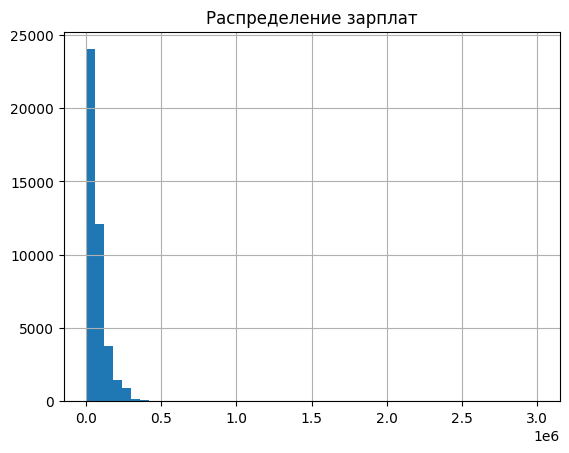

In [14]:
# Базовая статистика
print(df_full['salary'].describe())

# Гистограмма
import matplotlib.pyplot as plt
df_full['salary'].hist(bins=50)
plt.title('Распределение зарплат')
plt.show()

In [15]:
print(df_full['job_title'].nunique())
print(df_full['city_relocate'].nunique())

14929
10063


In [16]:
df_full.to_csv('hh_cleaned.csv', index=False, encoding='utf-8')

In [17]:
dst-3.0_16_1_hh_database.csv
*.xlsx
__pycache__/

SyntaxError: invalid decimal literal (1589695053.py, line 1)

In [18]:
git init
git add hh_cleaned.csv .gitignore
git commit -m "clean hh data"

SyntaxError: invalid syntax (953535638.py, line 1)

<class 'pandas.DataFrame'>
RangeIndex: 44744 entries, 0 to 44743
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   gender_age       44744 non-null  str    
 1   salary           42471 non-null  float64
 2   job_title        44744 non-null  str    
 3   city_relocate    44744 non-null  str    
 4   employment       44744 non-null  str    
 5   schedule         44744 non-null  str    
 6   work_experience  44576 non-null  str    
 7   last_job         44743 non-null  str    
 8   last_position    44742 non-null  str    
 9   education        44744 non-null  str    
 10  update_date      44744 non-null  str    
 11  car              44744 non-null  str    
dtypes: float64(1), str(11)
memory usage: 4.1 MB
None
count    4.247100e+04
mean     7.624488e+04
std      6.284789e+04
min      1.000000e+00
25%      4.000000e+04
50%      6.000000e+04
75%      9.500000e+04
max      3.000000e+06
Name: salary, dtype: float64

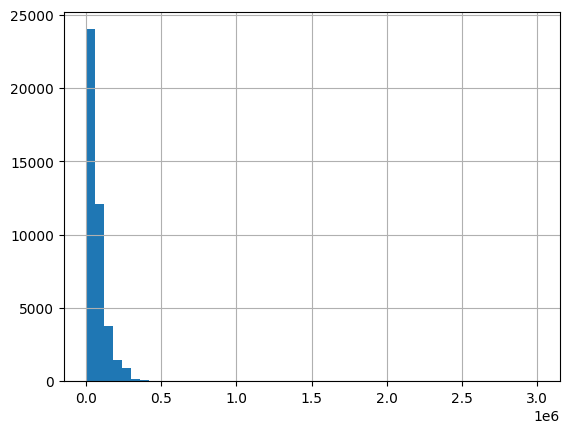

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

df = pd.read_csv('hh_cleaned.csv')
print(df.info())
print(df['salary'].describe())
df['salary'].hist(bins=50)
plt.show()

In [20]:
# Извлекаем возраст (цифры из строки типа "Мужчина , 39 лет")
df['age'] = df['gender_age'].str.extract(r'(\d+)').astype(float)
print(df['age'].describe())

count    44744.000000
mean        32.196741
std          7.929800
min         14.000000
25%         27.000000
50%         31.000000
75%         36.000000
max        100.000000
Name: age, dtype: float64


In [21]:
df['city'] = df['city_relocate'].str.split(',').str[0]
print(df['city'].head(10))
print(f"Уникальных городов: {df['city'].nunique()}")

0    Советск (Калининградская область) 
1                              Королев 
2                                Тверь 
3                              Саратов 
4                               Москва 
5                         Старый Оскол 
6                               Москва 
7                               Москва 
8                               Москва 
9                               Москва 
Name: city, dtype: object
Уникальных городов: 985


In [22]:
top_cities = df['city'].value_counts().head(20).index
df['city_group'] = df['city'].apply(lambda x: x if x in top_cities else 'Другое')
print(df['city_group'].value_counts())

city_group
Москва              16621
Другое              13229
Санкт-Петербург      4937
Краснодар            1066
Новосибирск           958
Казань                872
Екатеринбург          734
Самара                703
Ростов-на-Дону        607
Нижний Новгород       598
Уфа                   565
Алматы                556
Воронеж               538
Пермь                 445
Красноярск            407
Тюмень                355
Минск                 353
Челябинск             330
Омск                  303
Томск                 285
Ярославль             282
Name: count, dtype: int64


In [23]:
# Сохрани обновлённый датасет
df.to_csv('hh_cleaned.csv', index=False)

In [3]:
import re

def extract_years(exp):
    if pd.isna(exp):
        return 0
    years = re.search(r'(\d+)\s*год', exp)
    months = re.search(r'(\d+)\s*месяц', exp)
    y = int(years.group(1)) if years else 0
    m = int(months.group(1)) if months else 0
    return round(y + m/12, 1)

df['exp_years'] = df['work_experience'].apply(extract_years)
print(df['exp_years'].describe())

KeyError: 'work_experience'

In [4]:
print(df.columns.tolist())

['Пол, возраст', 'ЗП', 'Ищет работу на должность:', 'Город, переезд, командировки', 'Занятость', 'График', 'Опыт работы', 'Последнее/нынешнее место работы', 'Последняя/нынешняя должность', 'Образование и ВУЗ', 'Обновление резюме', 'Авто']
